In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# A more Detailed
import warnings
warnings.filterwarnings('ignore')

In [29]:
load_directory = '/content/drive/MyDrive/Colab Notebooks/My Book | Football: A Complete Statistical History Almanack'

df_eng = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/My Book | Football: A Complete Statistical History Almanack/df_eng.xlsx')
df_ita = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/My Book | Football: A Complete Statistical History Almanack/df_ita.xlsx')
df_esp = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/My Book | Football: A Complete Statistical History Almanack/df_esp.xlsx')
df_ger = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/My Book | Football: A Complete Statistical History Almanack/df_ger.xlsx')
df_por = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/My Book | Football: A Complete Statistical History Almanack/df_por.xlsx')
df_fra = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/My Book | Football: A Complete Statistical History Almanack/df_fra.xlsx')

In [30]:
df = pd.concat([df_eng, df_ita, df_esp, df_ger, df_por, df_fra])

# Initially, I Grouped by this Operation Raw, and Saw a Team with a very Small Sample of Matches Played but a lot of
# PPG; so, I decided to, firstly, Filter out for Teams that had Played a Minimum of 1500 Matches in the First Division

df.drop_duplicates(inplace = True)
df = df[df["Matches"] > 1500].sort_values(by="PPG", ascending=False)

## Exploratory Data Analysis (EDA) & Visualization

In [31]:
pd.set_option('display.max_columns', None)

df.head(4)

,All-Time Domestic Position,Team,Matches,Win,Draw,Loss,GD,Total Points,Goals Scored,Goals Conceded,PPG,WPG,DPG,LPG,GSPG,GCPG,Country GSPG,Country GCPG,ΔGSPG From Country Avg.,ΔGCPG From Country Avg.,Country,HasWinningRecord
0,1,SL Benfica,2167,1491,419,257,3251,4892,4893,1642,2.257,0.688,0.193,0.119,2.258,0.758,1.061,1.542,1.197,-0.784,Portugal,NaN
1,2,FC Porto,2167,1491,407,269,2980,4874,4524,1544,2.249,0.688,0.188,0.124,2.088,0.713,1.061,1.542,1.027,-0.829,Portugal,NaN
2,3,Sporting CP,2167,1310,486,371,2286,4416,4127,1841,2.038,0.605,0.224,0.171,1.904,0.850,1.061,1.542,0.843,-0.692,Portugal,NaN
0,1,Bayern München,2043,1236,438,369,2381,4146,4610,2229,2.029,0.605,0.214,0.181,2.256,1.091,1.329,1.744,0.927,-0.653,Germany,NaN


In [32]:
df.drop(columns = ['HasWinningRecord'], axis = 1, inplace = True)
df.drop_duplicates(inplace = True)

print(df.info)

<bound method DataFrame.info of     All-Time Domestic Position             Team  Matches   Win  Draw  Loss  \
0                            1       SL Benfica     2167  1491   419   257   
1                            2         FC Porto     2167  1491   407   269   
2                            3      Sporting CP     2167  1310   486   371   
0                            1   Bayern München     2043  1236   438   369   
0                            1      Real Madrid     3064  1844   613   607   
..                         ...              ...      ...   ...   ...   ...   
26                          27   Southampton FC     1870   596   508   766   
13                          14       CA Osasuna     1542   499   393   650   
24                          25  Birmingham City     2306   724   583   999   
13                          14  Cagliari Calcio     1518   434   491   593   
12                          13  Real Valladolid     1654   502   437   715   

      GD  Total Points  Goals S

### Feature Engineering

In [33]:
# Standardized Measures and Percentiles for Final, Combined Table

from scipy.stats import zscore

df["Standardized Overall PPG"] = zscore(df["PPG"]).round(3)
df["Standardized Overall WPG"] = zscore(df["WPG"]).round(3)
df["Standardized Overall DPG"] = zscore(df["DPG"]).round(3)
df["Standardized Overall LPG"] = zscore(df["LPG"]).round(3)
df["Standardized Overall GSPG"] = zscore(df["GSPG"]).round(3)
df["Standardized Overall GCPG"] = zscore(df["GCPG"]).round(3)

In [34]:
grouped_measures = df.groupby('Country')[['WPG', 'DPG', 'LPG', 'PPG', 'ΔGSPG From Country Avg.',
                       'ΔGCPG From Country Avg.']].mean().round(3).sort_values('ΔGCPG From Country Avg.', ascending = False)

grouped_measures

,WPG,DPG,LPG,PPG,ΔGSPG From Country Avg.,ΔGCPG From Country Avg.
Country,,,,,,
England,0.382,0.244,0.374,1.390,0.150,-0.133
Spain,0.409,0.240,0.352,1.466,0.246,-0.268
Italy,0.389,0.301,0.310,1.464,0.304,-0.269
France,0.391,0.266,0.343,1.439,0.122,-0.270
Germany,0.426,0.253,0.322,1.530,0.372,-0.327
Portugal,0.485,0.237,0.278,1.691,0.537,-0.468


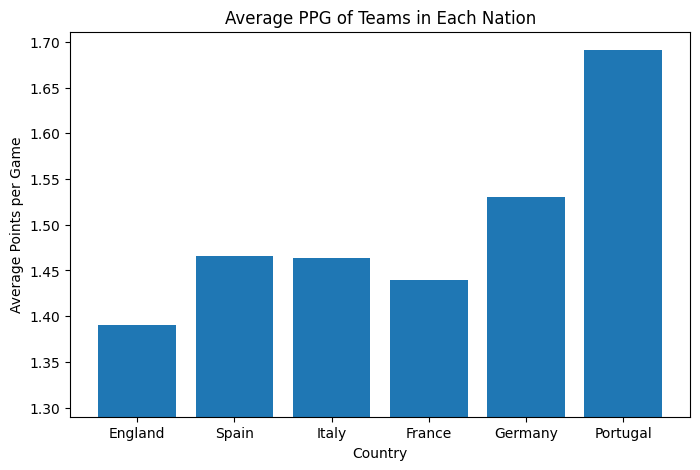

In [35]:
# Bar Graph

plt.figure(figsize=(8, 5))

plt.bar(x = grouped_measures.index, height = grouped_measures['PPG'])
plt.xlabel('Country')
plt.ylabel('Average Points per Game')
plt.ylim(grouped_measures['PPG'].min() - 0.1, grouped_measures['PPG'].max() + 0.02)
plt.title('Average PPG of Teams in Each Nation')
plt.show()

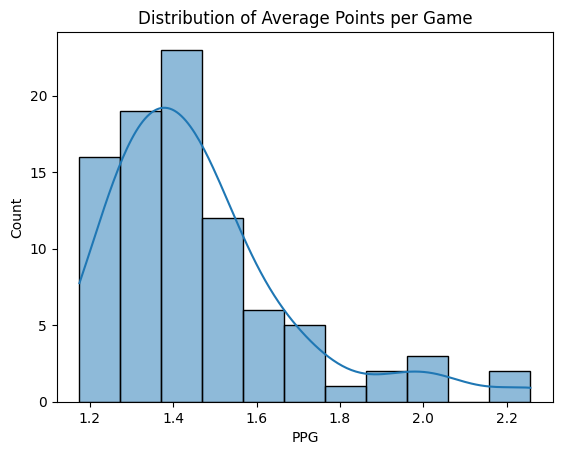

In [36]:
sns.histplot(df['PPG'], kde = True)
plt.title('Distribution of Average Points per Game')
plt.show()

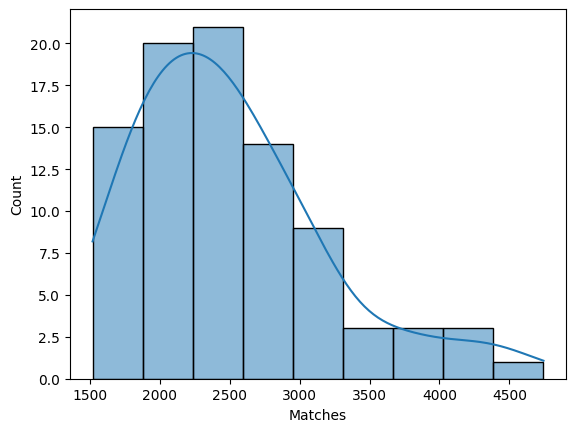

In [37]:
sns.histplot(df['Matches'], kde = True)
plt.show()

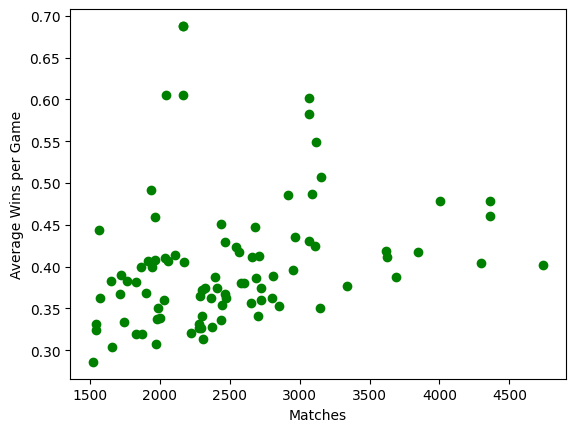

In [38]:
# Does the Amount of Time Spent in the First Division Correlate to more Wins on Average, due to the Experience earned?
plt.scatter(df['Matches'], df['WPG'], color = 'g')
plt.xlabel('Matches')
plt.ylabel('Average Wins per Game')
plt.show()

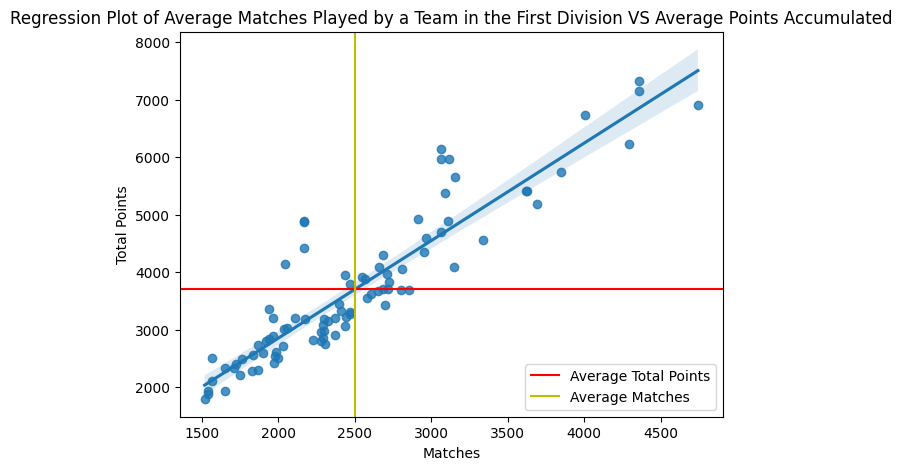

In [39]:
# Intuitively, it is Understandable that the more a Team plays, the more Total Points it will Accumulate
# But it is Better to Statistically Analyze it

plt.figure(figsize = (7, 5))
sns.regplot(x = df['Matches'], y = df['Total Points'])
plt.axhline(y = df['Total Points'].mean(), color = 'r', label = 'Average Total Points')
plt.axvline(x = df['Matches'].mean(), color = 'y', label = 'Average Matches')

plt.title("Regression Plot of Average Matches Played by a Team in the First Division VS Average Points Accumulated")
plt.legend()
plt.show() # A Linear Relationship, of course, but it does have Outliers/Residuals who did not Perform as well despite Playing a lot

In [40]:
df.groupby("Country")[["PPG", "WPG", "DPG", "LPG", "GSPG", "GCPG", "ΔGCPG From Country Avg.", "ΔGSPG From Country Avg."]].mean().round(3)

,PPG,WPG,DPG,LPG,GSPG,GCPG,ΔGCPG From Country Avg.,ΔGSPG From Country Avg.
Country,,,,,,,,
England,1.390,0.382,0.244,0.374,1.513,1.490,-0.133,0.150
France,1.439,0.391,0.266,0.343,1.428,1.316,-0.270,0.122
Germany,1.530,0.426,0.253,0.322,1.701,1.417,-0.327,0.372
Italy,1.464,0.389,0.301,0.310,1.384,1.197,-0.269,0.304
Portugal,1.691,0.485,0.237,0.278,1.598,1.074,-0.468,0.537
Spain,1.466,0.409,0.240,0.352,1.506,1.356,-0.268,0.246


## Pivot Tables for some Advanced Analysis

In [41]:
df[df['All-Time Domestic Position'] <= 5].pivot_table(index = ['Country', 'All-Time Domestic Position'],
               values = ["PPG", "WPG", "DPG", "LPG", "GSPG", "GCPG", "ΔGSPG From Country Avg.", "ΔGCPG From Country Avg."], aggfunc = np.mean)

DPG   GCPG   GSPG    LPG    PPG    WPG  \
Country  All-Time Domestic Position                                             
England  1                           0.247  1.199  1.688  0.275  1.681  0.478   
         2                           0.254  1.245  1.670  0.285  1.638  0.461   
         3                           0.252  1.387  1.533  0.346  1.457  0.402   
         4                           0.245  1.272  1.715  0.276  1.681  0.479   
         5                           0.236  1.490  1.615  0.360  1.449  0.404   
France   1                           0.255  1.278  1.615  0.297  1.599  0.448   
         2                           0.271  1.133  1.529  0.278  1.624  0.451   
         3                           0.272  1.227  1.477  0.305  1.540  0.423   
         4                           0.262  1.303  1.519  0.321  1.512  0.417   
         5                           0.250  1.302  1.509  0.319  1.541  0.430   
Germany  1                           0.214  1.091  2.256  0.181  2.029  0.605   
         2                           0.248  1.405  1.828  0.293  1.625  0.459   
         3                           0.251  1.479  1.651  0.340  1.480  0.410   
         4                           0.244  1.469  1.652  0.349  1.467  0.408   
         5                           0.263  1.471  1.697  0.337  1.464  0.400   
Italy    1                           0.272  0.943  1.738  0.179  1.916  0.549   
         2                           0.273  1.026  1.708  0.220  1.793  0.507   
         3                           0.292  1.028  1.644  0.221  1.741  0.487   
         4                           0.295  1.131  1.476  0.280  1.570  0.425   
         5                           0.303  1.159  1.393  0.301  1.475  0.396   
Portugal 1                           0.193  0.758  2.258  0.119  2.257  0.688   
         2                           0.188  0.713  2.088  0.124  2.249  0.688   
         3                           0.224  0.850  1.904  0.171  2.038  0.605   
         4                           0.247  1.220  1.363  0.346  1.468  0.407   
         5                           0.243  1.283  1.360  0.350  1.464  0.407   
Spain    1                           0.200  1.114  2.140  0.198  2.006  0.602   
         2                           0.201  1.107  2.146  0.216  1.950  0.583   
         3                           0.230  1.221  1.725  0.283  1.689  0.486   
         4                           0.239  1.311  1.633  0.330  1.532  0.431   
         5                           0.239  1.296  1.613  0.325  1.548  0.436   

                                     ΔGCPG From Country Avg.  \
Country  All-Time Domestic Position                            
England  1                                            -0.424   
         2                                            -0.378   
         3                                            -0.236   
         4                                            -0.351   
         5                                            -0.133   
France   1                                            -0.307   
         2                                            -0.452   
         3                                            -0.358   
         4                                            -0.282   
         5                                            -0.283   
Germany  1                                            -0.653   
         2                                            -0.339   
         3                                            -0.265   
         4                                            -0.275   
         5                                            -0.273   
Italy    1                                            -0.523   
         2                                            -0.440   
         3                                            -0.438   
         4                                            -0.335   
         5                                            -0.307   
Portugal 1                            

In [42]:
df[df['All-Time Domestic Position'] <= 5].pivot_table(index = ['Country', 'All-Time Domestic Position'],
                  values = ['Standardized Overall PPG', 'Standardized Overall WPG', 'Standardized Overall DPG', 'Standardized Overall LPG', 'Standardized Overall GSPG', 'Standardized Overall GCPG'],
                        aggfunc = 'mean')

Standardized Overall DPG  \
Country  All-Time Domestic Position                             
England  1                                             -0.352   
         2                                             -0.090   
         3                                             -0.165   
         4                                             -0.427   
         5                                             -0.763   
France   1                                             -0.053   
         2                                              0.546   
         3                                              0.583   
         4                                              0.209   
         5                                             -0.240   
Germany  1                                             -1.586   
         2                                             -0.314   
         3                                             -0.202   
         4                                             -0.464   
         5                                              0.247   
Italy    1                                              0.583   
         2                                              0.621   
         3                                              1.331   
         4                                              1.443   
         5                                              1.743   
Portugal 1                                             -2.371   
         2                                             -2.558   
         3                                             -1.212   
         4                                             -0.352   
         5                                             -0.501   
Spain    1                                             -2.110   
         2                                             -2.072   
         3                                             -0.988   
         4                                             -0.651   
         5                                             -0.651   

                                     Standardized Overall GCPG  \
Country  All-Time Domestic Position                              
England  1                                              -0.767   
         2                                              -0.527   
         3                                               0.215   
         4                                              -0.386   
         5                                               0.752   
France   1                                              -0.354   
         2                                              -1.111   
         3                                              -0.621   
         4                                              -0.224   
         5                                              -0.229   
Germany  1                                              -1.331   
         2                                               0.308   
         3                                               0.695   
         4                                               0.643   
         5                                               0.653   
Italy    1                                              -2.103   
         2                                              -1.670   
         3                                              -1.659   
         4                                              -1.122   
         5                                              -0.976   
Portugal 1                                              -3.069   
         2                                              -3.304   
         3                                              -2.588   
         4                                              -0.657   
         5                                              -0.328   
Spain    1                                              -1.210   
         2                                              -1.247   
         3                                

In [43]:
dfnums = df.select_dtypes(include = np.number)

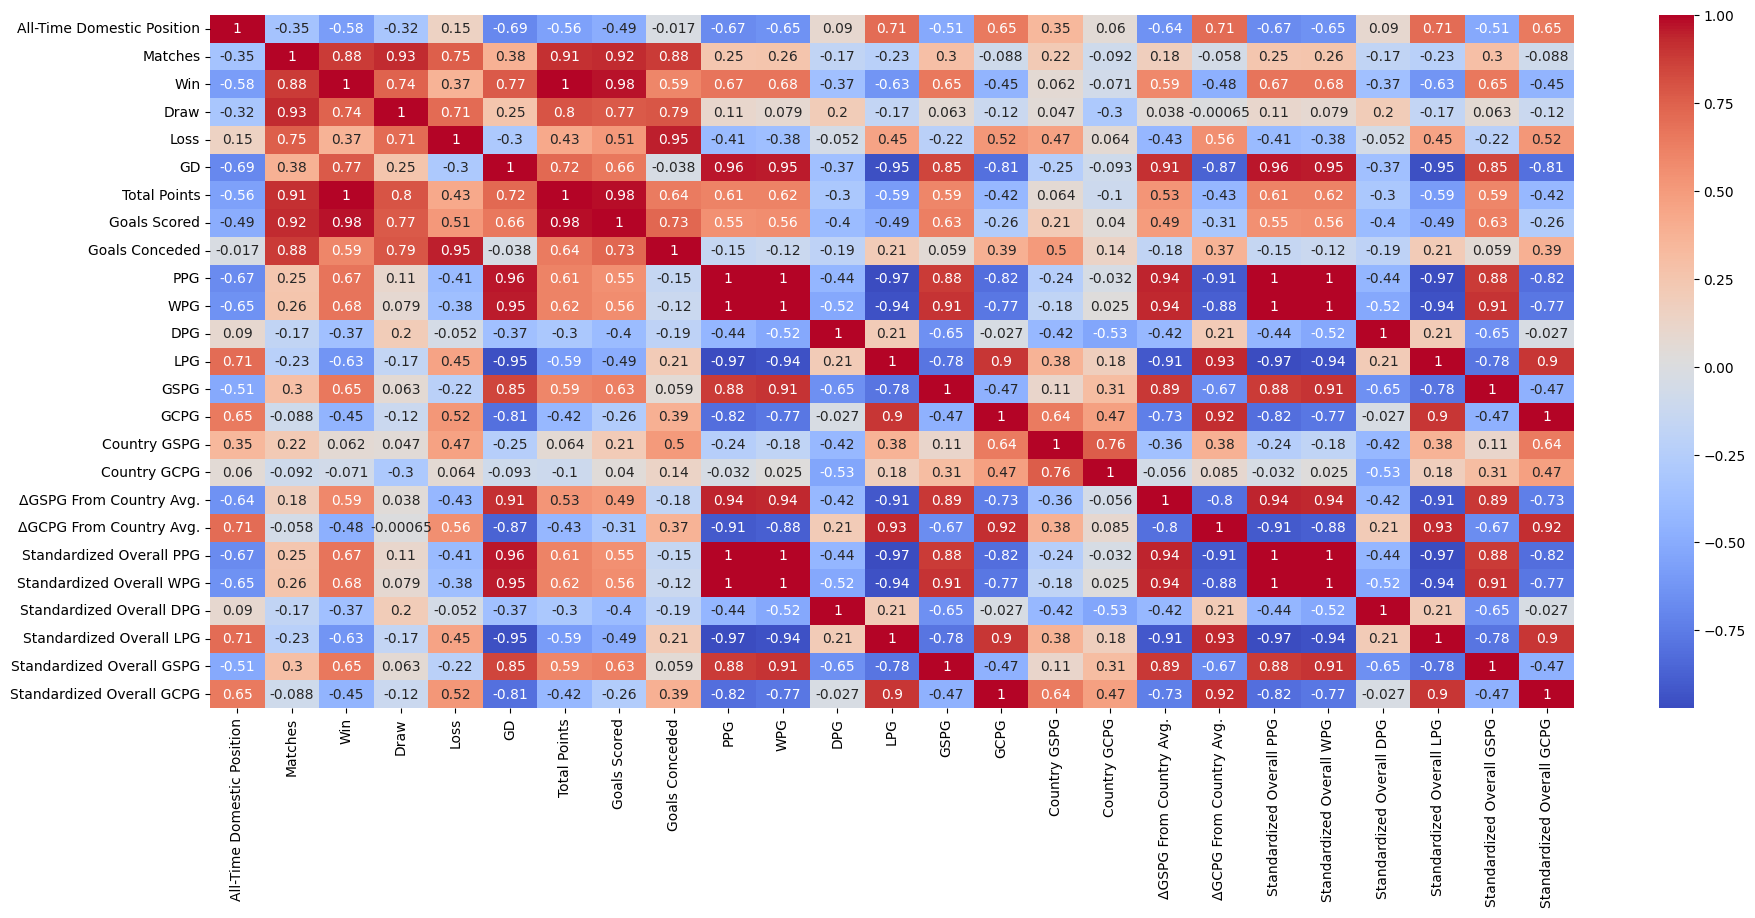

In [44]:
plt.figure(figsize = (22, 9))
sns.heatmap(dfnums.corr(), annot = True, cmap = 'coolwarm')
plt.show()

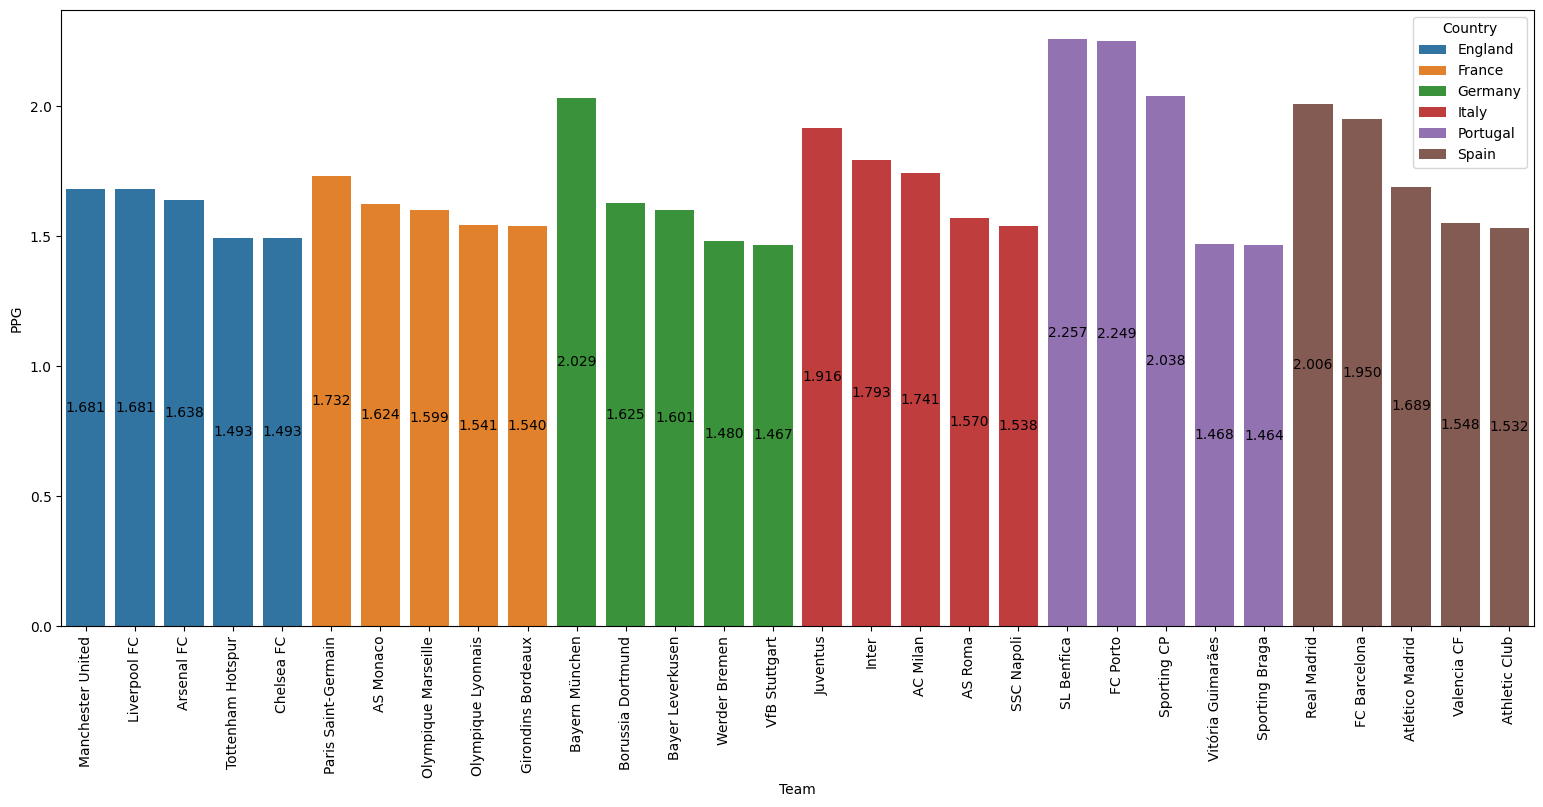

In [45]:
# Bar Chart of Top 5 PPG Teams by Country
topfives = df.groupby('Country').apply(lambda x: x.nlargest(5, 'PPG')).reset_index(drop = True)

plt.figure(figsize = (19, 8))
ax = sns.barplot(data = topfives, x = 'Team', y = 'PPG', hue = 'Country')
plt.xticks(rotation = 90)
# Add the PPG values on the bars
for container in ax.containers:
    ax.bar_label(container, fmt = '%.3f', label_type = 'center', fontsize = 10)
plt.show()

In [46]:
df.filter(like = 'Standardized').columns

Index(['Standardized Overall PPG', 'Standardized Overall WPG',
       'Standardized Overall DPG', 'Standardized Overall LPG',
       'Standardized Overall GSPG', 'Standardized Overall GCPG'],
      dtype='object')

<Figure size 1200x700 with 0 Axes>

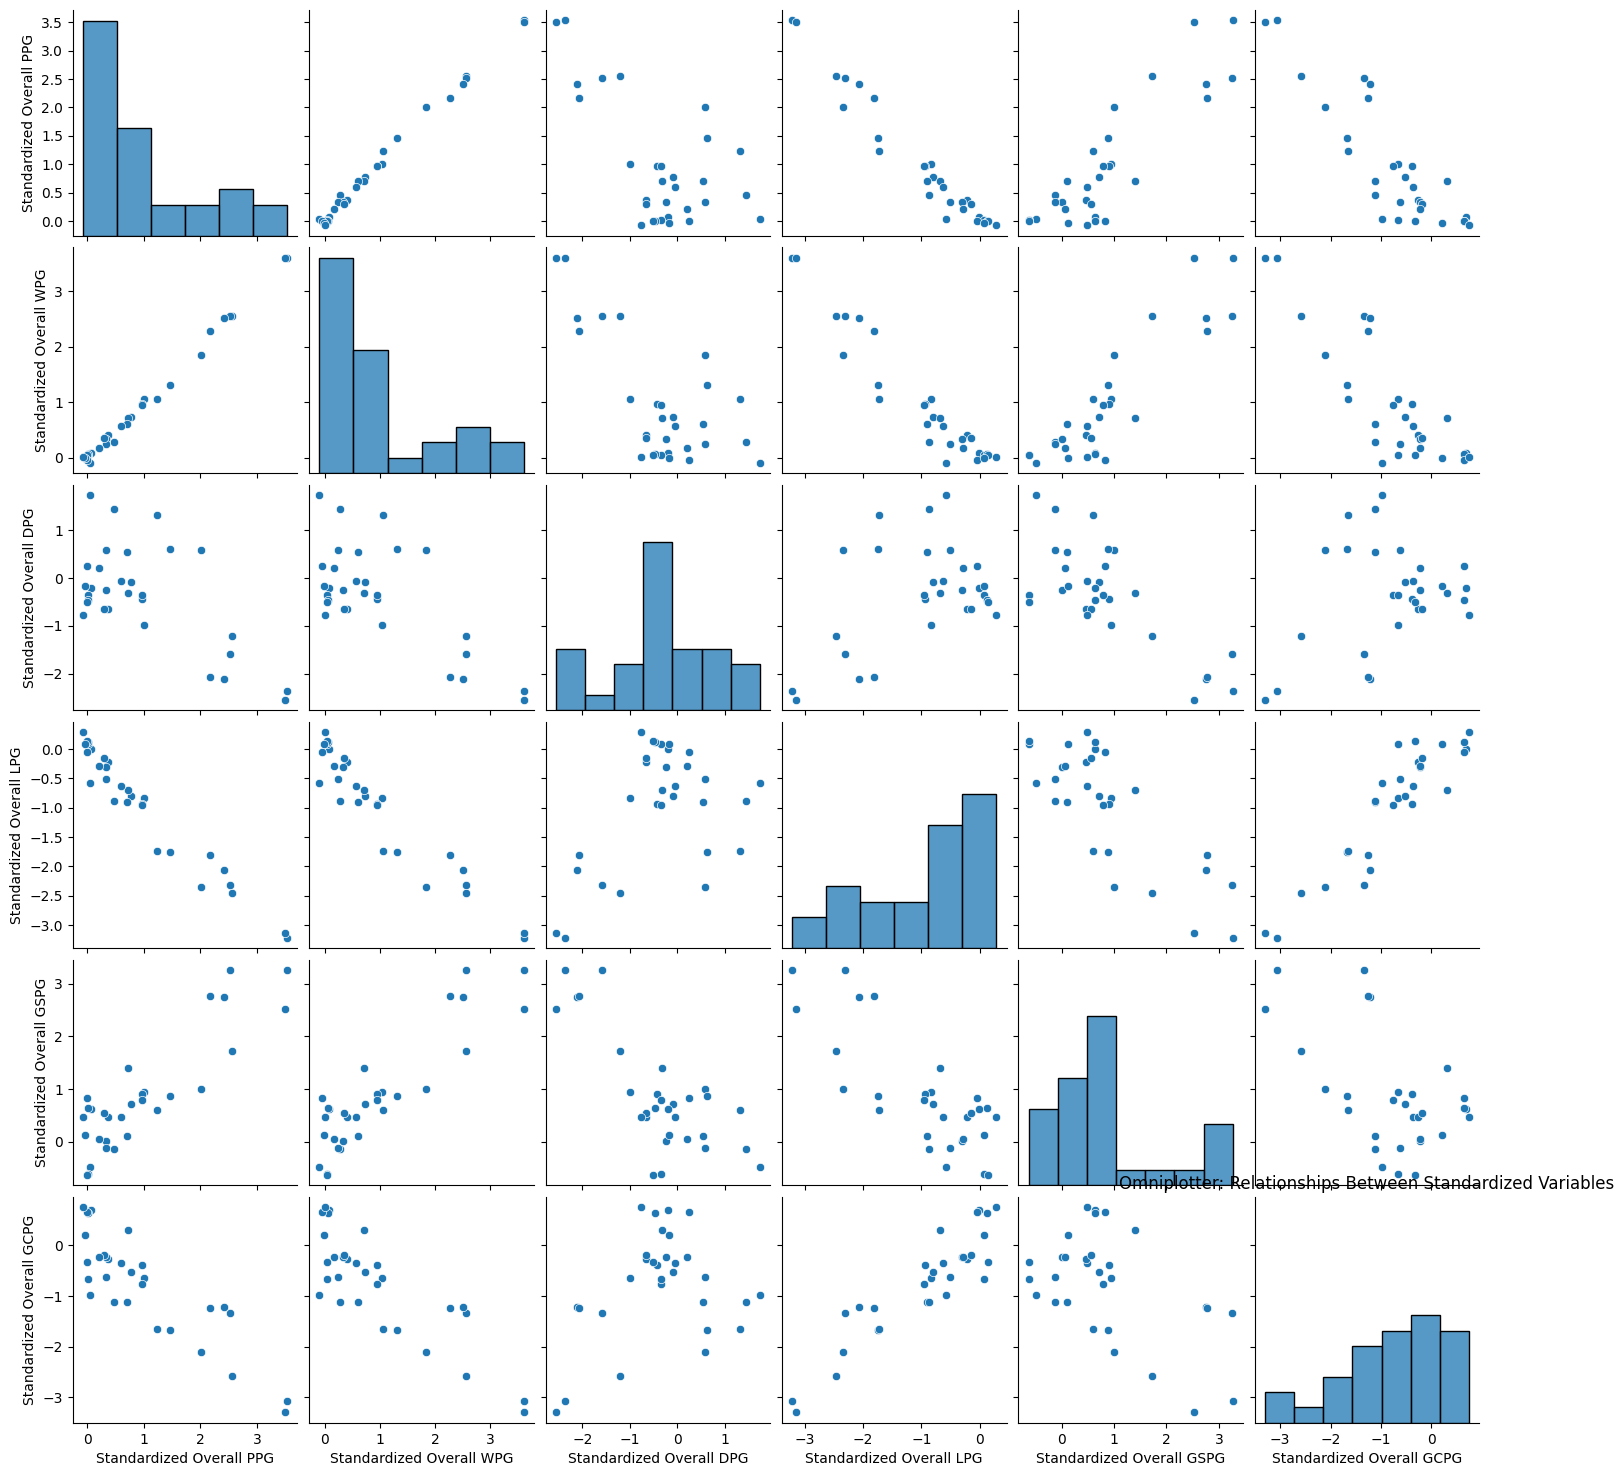

In [47]:
plt.figure(figsize = (12, 7))
sns.pairplot(df[df['All-Time Domestic Position'] <= 5][['Standardized Overall PPG', 'Standardized Overall WPG',
                                                      'Standardized Overall DPG', 'Standardized Overall LPG',
                                                      'Standardized Overall GSPG', 'Standardized Overall GCPG']])
plt.title('Omniplotter: Relationships Between Standardized Variables')
plt.show()

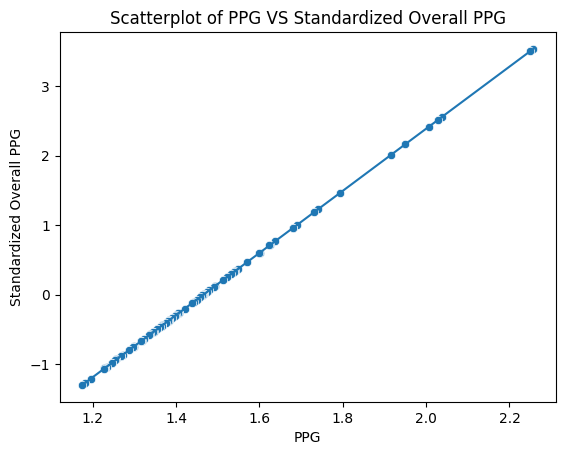

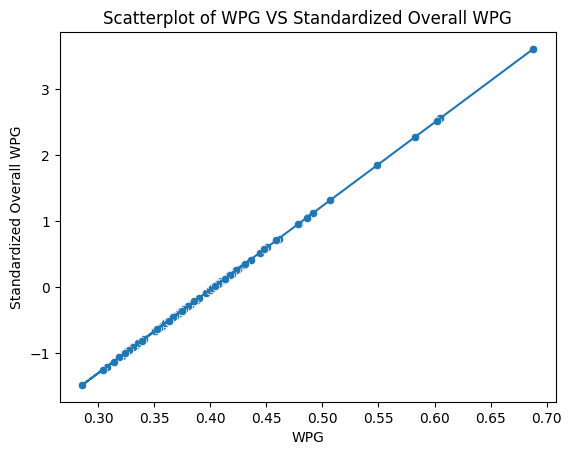

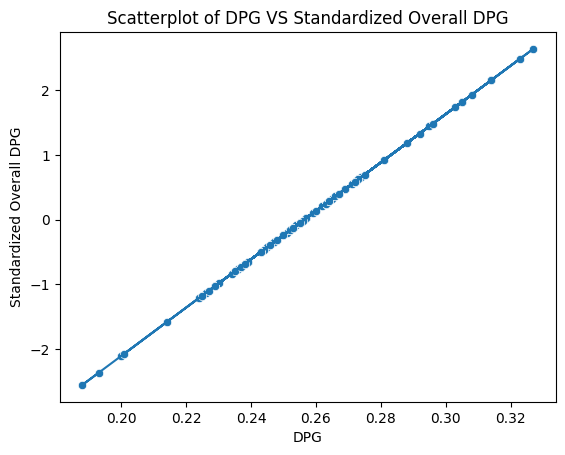

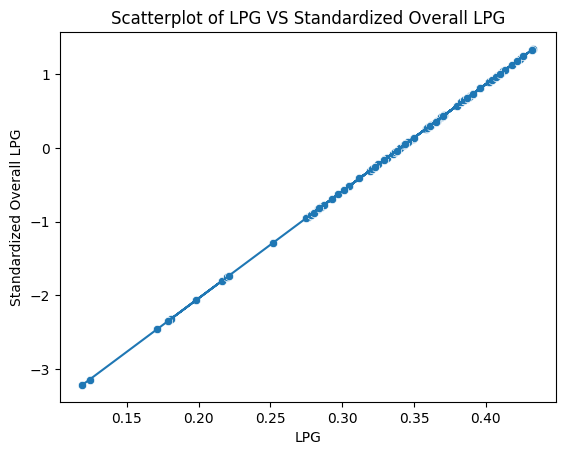

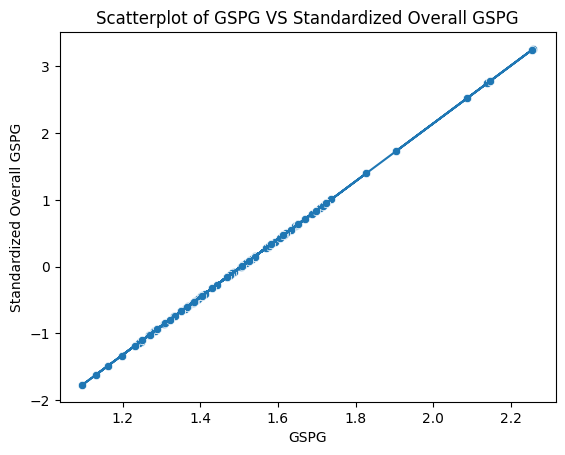

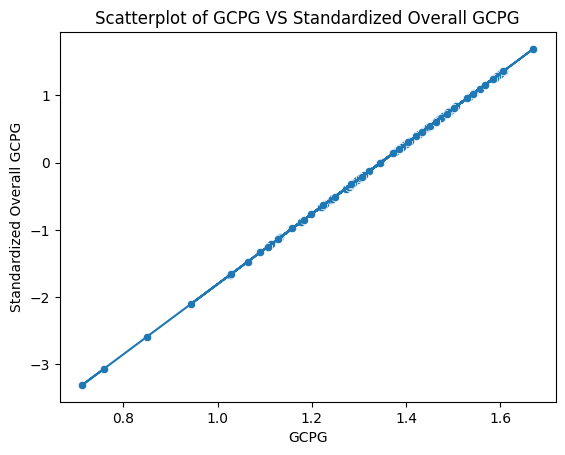

In [48]:
nums = df[['PPG', 'WPG', 'DPG', 'LPG', 'GSPG', 'GCPG']]
stds = df[['Standardized Overall PPG', 'Standardized Overall WPG', 'Standardized Overall DPG', 'Standardized Overall LPG',
       'Standardized Overall GSPG', 'Standardized Overall GCPG']]

for x, y in zip(nums.columns, stds.columns):
  sns.scatterplot(x = nums[x], y = stds[y])
  plt.plot(nums[x], stds[y])
  plt.title(f"Scatterplot of {x} VS {y}")
  plt.show()

# There we go: they all exhibit Perfectly Linear Relationships
# Regular and Standardized Metrics are Positively Related
# Any of these Features is good to use a Target variable based on the others as Predictors

# Machine Learning

#### The focus will be on the vital and more accurate Feature of Points per Game (PPG).
---

#### **Feature Engineering**

In [49]:
df['Standardized Score'] = df['Standardized Overall PPG'] + df['Standardized Overall WPG'] + df['Standardized Overall DPG'] + df['Standardized Overall LPG'] + df['Standardized Overall GSPG'] + df['Standardized Overall GCPG']

In [50]:
df['Expected Max Points'] = (df['PPG'] * df['Matches'].max()).astype(int)

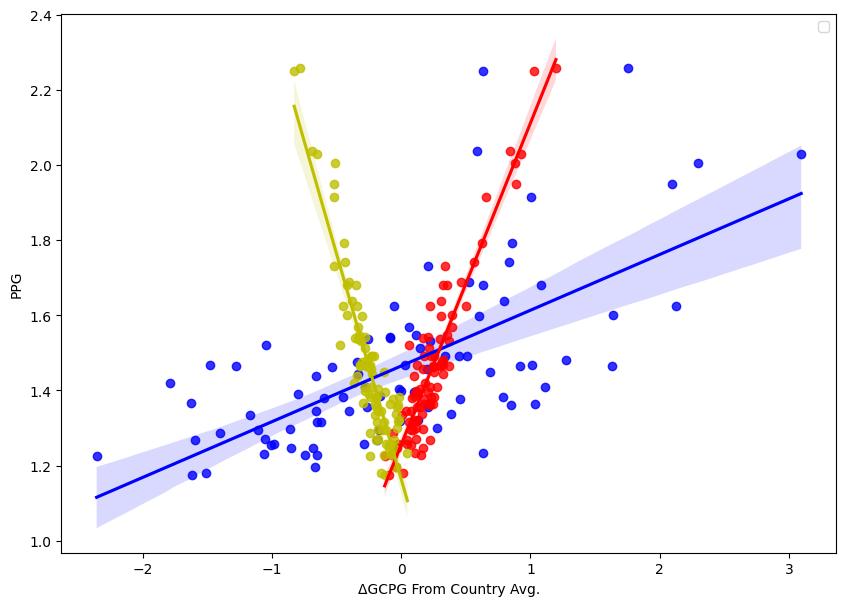

In [51]:
# Seeing if these Features would also be Significant Predictors
plt.figure(figsize = (10, 7))
sns.regplot(x = df['Standardized Score'], y = df['PPG'], color = 'b')
sns.regplot(x = df['ΔGSPG From Country Avg.'], y = df['PPG'], color = 'r')
sns.regplot(x = df['ΔGCPG From Country Avg.'], y = df['PPG'], color = 'y')
plt.legend()
plt.show()

# Better to Proceed with the earlier Features Only

________________________________________________________________________________
## Multiple Regression

In [52]:
features = ['WPG', 'DPG', 'LPG', 'GSPG', 'GCPG']

X = df[features]
y = df['PPG']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

In [53]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr_model = lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [54]:
# Residuals
diff_lr = y_test - y_pred_lr

In [55]:
# Creating Series for Predicted values and the Difference with the same Index as "y_test"
y_pred_lr_series = pd.Series(y_pred_lr, index = y_test.index).round(2)
diff_lr_series = pd.Series(diff_lr, index = y_test.index).round(2)

# Concatenating the Series, now aligned by index
residuals_dt = pd.concat([y_test, y_pred_lr_series, diff_lr_series], axis = 1)
residuals_dt.columns = ["Actual Result", "Predicted Result", "Difference"]
residuals_dt.head(5)

,Actual Result,Predicted Result,Difference
9,1.408,1.41,0.00
14,1.376,1.38,-0.00
4,1.475,1.49,-0.01
0,1.681,1.68,0.00
11,1.384,1.38,0.00


In [56]:
from sklearn.metrics import mean_squared_error as mse, mean_absolute_error as mae, root_mean_squared_error as rmse, r2_score as r2, accuracy_score as acc
from sklearn.model_selection import cross_val_score

print("The Mean Squared Error is: {}".format(round(mse(y_test, y_pred_lr), 2)))
print("The Mean Absolute Error is: {}".format(round(mae(y_test, y_pred_lr), 2)))
print("The Root Mean Squared Error is: {}".format(round(rmse(y_test, y_pred_lr), 2)))

print("")

# Performing Cross-Validation of 5 Folds; instead of just once, splitting the Data into 5 Random parts and Performing Training and Testing 5 Times Across & Randomly
scores = cross_val_score(lr_model, X, y, cv = 5, scoring = 'r2')

# print("R-squared scores for each fold:", scores)
print(f"The Standard Deviation of Cross-Validation Scores is: {np.std(scores):.3f}") # Very low (0.004), indicating Consistent Model Performance
# Mean of Cross-Validation Scores; The Ultimate R-Squared Value/Score of the Model
print(f"The Final R2 Score of the Model is: {np.mean(scores)*100:.1f}%") # an Average 99.5% R-Squared value

# The Model IS PERFECTLY FINE to proceed with!

The Mean Squared Error is: 0.0
The Mean Absolute Error is: 0.0
The Root Mean Squared Error is: 0.0

The Standard Deviation of Cross-Validation Scores is: 0.004
The Final R2 Score of the Model is: 99.5%


In [57]:
print(f"The Intercept for this Model was: {lr_model.intercept_.round(3)}")

pd.DataFrame(lr_model.coef_.round(3), X.columns, columns = ['Coefficient'])

The Intercept for this Model was: 1.724


,Coefficient
WPG,1.270
DPG,-0.755
LPG,-1.706
GSPG,0.004
GCPG,-0.002


In [58]:
print(f"The equation for this Linear Regression model is: {lr_model.intercept_.round(3)} + \n {lr_model.feature_names_in_[0]}*{lr_model.coef_[0].round(3)} + {lr_model.feature_names_in_[1]}*{lr_model.coef_[1].round(3)} + \n {lr_model.feature_names_in_[2]}*{lr_model.coef_[2].round(3)} + {lr_model.feature_names_in_[3]}*{lr_model.coef_[3].round(3)} + {lr_model.feature_names_in_[4]}*{lr_model.coef_[4].round(3)}")

The equation for this Linear Regression model is: 1.724 + 
 WPG*1.27 + DPG*-0.755 + 
 LPG*-1.706 + GSPG*0.004 + GCPG*-0.002


In [59]:
# Ordinary Least Squares (OLS) Regression for Detailed Statistical Analysis & Exploring Relationships
import statsmodels.api as sm

# Adding a Constant to the Independent
X_ols = sm.add_constant(X)

model_ols = sm.OLS(y, X_ols).fit()

model_ols.summary()

# Three of the Coefficients have Statistically INSIGNIFICANT p-values (> 0.05)
# However, the Predictive Performance of the Model was near-Perfect (R-Squared score is near 100%, and MSE and RMSE and MAE are all 0)
# Since the focus of this Project is more on Predictive Modeling and not so much on Explanatory Modeling, I will keep these Coefficients

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    PPG   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.519e+05
Date:                Tue, 27 May 2025   Prob (F-statistic):          8.22e-163
Time:                        21:05:22   Log-Likelihood:                 412.87
No. Observations:                  89   AIC:                            -813.7
Df Residuals:                      83   BIC:                            -798.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4935      0.540      2.764      0.007       0.419       2.568
WPG            1.5070      0.540      2.789      0.007       0.432       2.582
DPG           -0.5285      0.541     -0.976      0.332      -1.606       0.548
LPG           -1.4752      0.541     -2.727      0.008      -2.551      -0.399
GSPG           0.0020      0.006      0.320      0.750      -0.010       0.014
GCPG          -0.0010      0.007     -0.138      0.891      -0.015       0.013
==============================================================================
Omnibus:                       82.878   Durbin-Watson:                   2.233
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              700.653
Skew:                          -2.968   Prob(JB):                    7.16e-153
Kurtosis:                      15.398   Cond. No.                     9.82e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.82e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Sample Prediction Using the Multiple Linear Regression Model:**

In [60]:
print(df[['WPG', 'DPG', 'LPG', 'GSPG', 'GCPG']].mean())
print(df['PPG'].mean())

WPG     0.403281
DPG     0.256404
LPG     0.340371
GSPG    1.505169
GCPG    1.345899
dtype: float64
1.4653146067415732


In [61]:
# Plugging in Average Measures for 'df', we get a Result nearly Identical to the Actual PPG

print(lr.predict([[0.403, 0.256, 0.340, 1.505, 1.346]]))

# Result: PPG = 1.466 - Extremely Close to the Actual Average PPG: 1.465!
# Our Regression Model is Predicting Very Accurately!

[1.46598812]


Key Findings:
*   This Multiple Regression model is a very Reliable predictor for calculating a Team's Overall Performance levels based on the crafted features.
Those features - WPG, DPG, LPG, GSPG, GCPG - were engineered to account for differences in the Matches Teams have played in the First Division, and proved very effective (e.g., Liverpool ranks first in the English First Division all-time by Total Points Earned; however, if adjusted for PPG and all Teams having played same number of Matches in the First Division, **Manchester United** and **Liverpool** would BOTH share the Top spot.

*   Wins per Game (WPG) is the most Significant Predictor for Points per Game (PPG), with a Coefficient value of 1.270: For every 1-unit increase in WPG, the PPG for a Team is expected to increase by 1.27 units (holding all other variables in the model constant).

**Concluding Tip:** After Plugging in the WPG, DPG, LPG, GSPG, and GCPG values, you can *multiply the resulting PPG with the Number of Matches the Team has played and get its "Total Points"* to see where it Ranks overall.

________________________________________________________________________________
## K-Means Clustering:

In [62]:
# Columns for Clustering (Best for the Singular, Combined Table for all Countries - like 'Country' and 'Expected Max Points')

x = df[["All-Time Domestic Position", "PPG"]].values

from sklearn.cluster import KMeans

wcss = []

for i in range(1, 9):
  kmeans = KMeans(n_clusters = i, init = 'k-means++') # "init": Initializes the Centroids, "n_clusters": no. of Clusters in each Iteration; will go from 1 to 8
  kmeans.fit(x)
  wcss.append(kmeans.inertia_)

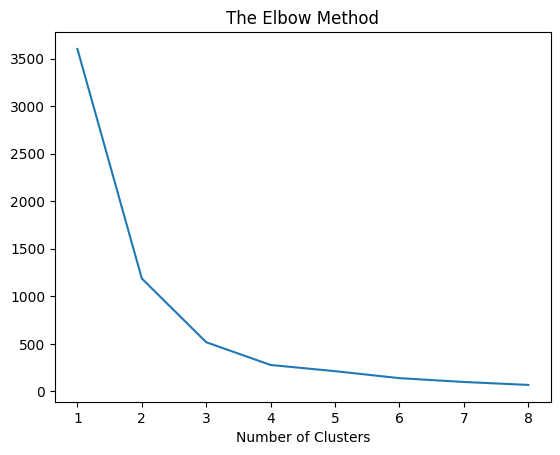

In [63]:
plt.plot(range(1, 9), wcss)
plt.title("The Elbow Method")
plt.xlabel("Number of Clusters")
plt.show() # 3 seems to be an Optimal Clusters amount

In [64]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++')
y_kmeans = kmeans.fit_predict(x)

In [65]:
df.reset_index(drop = True, inplace = True)

df_kmeans = pd.concat([df, pd.DataFrame(y_kmeans + 1, columns = ["Cluster no."])], axis = 1)
# df_kmeans[["All-Time Domestic Position", "PPG", "Cluster no."]].head(8)

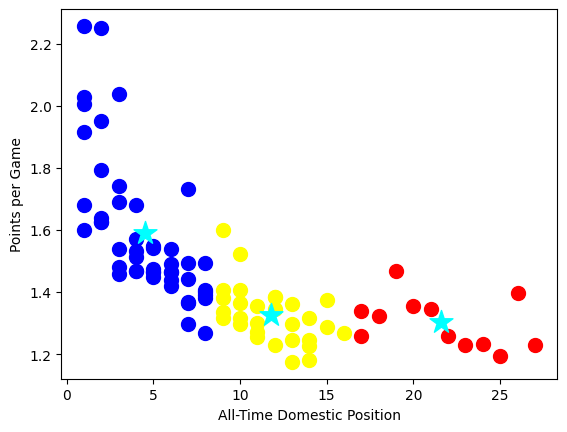

In [66]:
# Visualization

# Creating a Scatterplot based on WPG and PPG Ratio
plt.scatter(x[y_kmeans == 0, 0], x[y_kmeans == 0, 1], s = 100, c = 'red') # Cluster no.1
plt.scatter(x[y_kmeans == 1, 0], x[y_kmeans == 1, 1], s = 100, c = 'blue') # Cluster no.2
plt.scatter(x[y_kmeans == 2, 0], x[y_kmeans == 2, 1], s = 100, c = 'yellow') # Cluster no.3

# Adding Centroids to the Scatterplot
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'cyan', marker='*', label = 'Centroids')

plt.xlabel("All-Time Domestic Position")
plt.ylabel("Points per Game")
plt.show()

In [67]:
# Interpreting the Clusters with their Original, Unscaled units
# original_centroids = scaler.inverse_transform(kmeans.cluster_centers_)

print("Cluster Centers:")
for i, center in enumerate(kmeans.cluster_centers_):
    print(f"Cluster {i+1}: All-Time Domestic Position = {center[0]:.3f}, PPG = {center[1]:.3f}")

print("\nActual Ranges of Values in Each Cluster:")
for i in range(1, 4):
    cluster_data = df_kmeans[df_kmeans['Cluster no.'] == i][["All-Time Domestic Position", "PPG"]]
    print(f"\nCluster {i}:")
    print(f"  All-Time Domestic Position (Min): {cluster_data['All-Time Domestic Position'].min():.3f}, (Max): {cluster_data['All-Time Domestic Position'].max():.3f}")
    print(f"  PPG (Min): {cluster_data['PPG'].min():.3f}, (Max): {cluster_data['PPG'].max():.3f}")

Cluster Centers:
Cluster 1: All-Time Domestic Position = 21.583, PPG = 1.302
Cluster 2: All-Time Domestic Position = 4.500, PPG = 1.590
Cluster 3: All-Time Domestic Position = 11.759, PPG = 1.326

Actual Ranges of Values in Each Cluster:

Cluster 1:
  All-Time Domestic Position (Min): 17.000, (Max): 27.000
  PPG (Min): 1.195, (Max): 1.467

Cluster 2:
  All-Time Domestic Position (Min): 1.000, (Max): 8.000
  PPG (Min): 1.267, (Max): 2.257

Cluster 3:
  All-Time Domestic Position (Min): 9.000, (Max): 16.000
  PPG (Min): 1.175, (Max): 1.601


#### **Clustering Interpretation & Conclusion:**

*    In order to Finish in the top 4 all-time, a Team must be aiming to keep a record of around 1.619 PPG.
*    In contrast, if a Team has an overall PPG of 1.3 or below, it is most likely to find itself in the bottom half or bottom third of its Domestic League, in general, and the lower the PPG goes from here, the worse it becomes for the Team.

________________________________________________________________________________
## Random Forests Classifier:

Will classify Clubs into Categories based on their Aggregated Historic Performance.

Then, will use the Standardized Metrics as Features, since this is going to Predict Historic Performance Hierarchy for all European clubs and the Standardized Features compare Performance to European standards and not just Domestic ones.

In [68]:
# Feature Engineering the "Tier" Column by Binning Teams' PPGs into Different Tiers by their Positions in the Field's Quantiles
tiers = ['Historically Low Tier', 'Historically Mid-Tier', 'Historically Strong',
         'Historically Elite']

df['Tier'] = pd.qcut(df['PPG'], q = 4, labels = tiers)

In [69]:
X = df[['Standardized Overall PPG', 'Standardized Overall WPG', 'Standardized Overall DPG', 'Standardized Overall LPG', 'Standardized Overall GSPG', 'Standardized Overall GCPG']]
y = df['Tier']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 7) # CR7's 7! Haha.

In [70]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators = 100, random_state = 7)

rf_model = rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_train)

In [71]:
# Predicting Probabilities of a Team's Final Classification being in any of the Tiers
train_probs = rf_model.predict_proba(X_train)

In [72]:
# Model Evaluation

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, log_loss # Model Evaluation
from sklearn.model_selection import cross_val_score

# Computing the Accuracy of the Model
acc = accuracy_score(y_train, y_pred_rf)

# Computing the ROC-AUC Score of the Model
roc_auc = roc_auc_score(y_train, train_probs, multi_class = 'ovr') # More than 2 classes for y_train, so need to Specify the "multi_class" parameter as 'ovr' (one-vs-rest)

# Computing the Log-Loss (Lower ~ Better)
logloss = log_loss(y_train, train_probs)

# Printing the Performance Metrics of the Model!
print(f"Model Performance on Historical Data:")
print(f"Accuracy: {acc:.3f}")
print(f"ROC-AUC Score: {roc_auc:.3f}")
print(f"Log-Loss: {logloss:.3f}")

# Printing Detailed Classification Performance
print("\n Classification Report:")
print(classification_report(y_train, y_pred_rf))

# Displaying the Confusion Matrix (True VS Predicted Values)
print("Confusion Matrix:")
print(confusion_matrix(y_train, y_pred_rf)) # Looks good!

Model Performance on Historical Data:
Accuracy: 1.000
ROC-AUC Score: 1.000
Log-Loss: 0.048

 Classification Report:
                       precision    recall  f1-score   support

   Historically Elite       1.00      1.00      1.00        13
Historically Low Tier       1.00      1.00      1.00        21
Historically Mid-Tier       1.00      1.00      1.00        18
  Historically Strong       1.00      1.00      1.00        14

             accuracy                           1.00        66
            macro avg       1.00      1.00      1.00        66
         weighted avg       1.00      1.00      1.00        66

Confusion Matrix:
[[13  0  0  0]
 [ 0 21  0  0]
 [ 0  0 18  0]
 [ 0  0  0 14]]


Wrapping it all up!

In [73]:
# Using the entire DataFrame for Prediction
X_all = X.copy()

# Predicting Probabilities for the Entire Dataset
all_probs = rf_model.predict_proba(X_all)

# Assigning Column Names for the Probabilites
prob_cols = [f'{tier} Chance (%)' for tier in rf_model.classes_]

# Creating a DataFrame from "all_probs" with appropriate Column Names and the same Index as "df"
all_probs_df = pd.DataFrame(all_probs, columns = prob_cols, index = df.index)

# Concatening this Probability DataFrame^ with the Original
df = pd.concat([df, all_probs_df], axis = 1)

## df[['Team', 'Tier', 'Historically Elite Chance (%)', 'Historically Low Tier Chance (%)', 'Historically Mid-Tier Chance (%)', 'Historically Strong Chance (%)']]

#### **Conclusion & Suggestions:**
You can now Query and see for each Team its **Tier** Classification, as well as its Chances of being Classified into each Tier based on the all-important PPG (Points per Game) Feature.

In [74]:
# Checking for my Favorite Club
df.query("Team == 'Manchester United'") # Nice! I'm very Pleased with the Results, haha! 99% chance of being Classified Elite, and 1% for Strong!

# But we need to be much Better!

,All-Time Domestic Position,Team,Matches,Win,Draw,Loss,GD,Total Points,Goals Scored,Goals Conceded,PPG,WPG,DPG,LPG,GSPG,GCPG,Country GSPG,Country GCPG,ΔGSPG From Country Avg.,ΔGCPG From Country Avg.,Country,Standardized Overall PPG,Standardized Overall WPG,Standardized Overall DPG,Standardized Overall LPG,Standardized Overall GSPG,Standardized Overall GCPG,Standardized Score,Expected Max Points,Tier,Historically Elite Chance (%),Historically Low Tier Chance (%),Historically Mid-Tier Chance (%),Historically Strong Chance (%)
11,4,Manchester United,4004,1916,982,1106,1770,6730,6865,5095,1.681,0.479,0.245,0.276,1.715,1.272,1.363,1.623,0.352,-0.351,England,0.964,0.959,-0.427,-0.935,0.909,-0.386,1.084,7974,Historically Elite,0.99,0.0,0.0,0.01


In [75]:
# Let's Check How Spanish Teams do
df.query("Country == 'Spain'").sort_values('Expected Max Points', ascending = False).head(4)

,All-Time Domestic Position,Team,Matches,Win,Draw,Loss,GD,Total Points,Goals Scored,Goals Conceded,PPG,WPG,DPG,LPG,GSPG,GCPG,Country GSPG,Country GCPG,ΔGSPG From Country Avg.,ΔGCPG From Country Avg.,Country,Standardized Overall PPG,Standardized Overall WPG,Standardized Overall DPG,Standardized Overall LPG,Standardized Overall GSPG,Standardized Overall GCPG,Standardized Score,Expected Max Points,Tier,Historically Elite Chance (%),Historically Low Tier Chance (%),Historically Mid-Tier Chance (%),Historically Strong Chance (%)
4,1,Real Madrid,3064,1844,613,607,3143,6145,6557,3414,2.006,0.602,0.200,0.198,2.140,1.114,1.26,1.625,0.880,-0.511,Spain,2.416,2.517,-2.110,-2.067,2.750,-1.210,2.296,9516,Historically Elite,1.00,0.0,0.0,0.00
5,2,FC Barcelona,3064,1786,617,661,3181,5975,6574,3393,1.950,0.583,0.201,0.216,2.146,1.107,1.26,1.625,0.886,-0.518,Spain,2.166,2.277,-2.072,-1.806,2.776,-1.247,2.094,9250,Historically Elite,1.00,0.0,0.0,0.00
10,3,Atlético Madrid,2916,1418,672,826,1470,4926,5030,3560,1.689,0.486,0.230,0.283,1.725,1.221,1.26,1.625,0.465,-0.404,Spain,0.999,1.048,-0.988,-0.833,0.952,-0.652,0.526,8012,Historically Elite,1.00,0.0,0.0,0.00
19,5,Valencia CF,2966,1294,709,963,940,4591,4783,3843,1.548,0.436,0.239,0.325,1.613,1.296,1.26,1.625,0.353,-0.329,Spain,0.369,0.414,-0.651,-0.223,0.467,-0.260,0.116,7343,Historically Elite,0.78,0.0,0.0,0.22
